# TSA — Week 2 Python Lab
## Explore time-series patterns using Phnom Penh precipitation

**Student:** Heng Hour  |  **Group:** 9  |  **GitHub repository:** https://github.com/hengXiaoHour/tsa-course

**Submission title:** Week 2 Homework – Phnom Penh Rainfall – Heng Hour

**Learning outcomes:** check the time index and monthly coverage; make a time plot; compare years in a seasonal plot; make a *real seasonal subseries plot*; support interpretations with evidence.

**Time:** ~75–90 minutes. Run cells in order, discuss the questions with a partner, and write answers in the blank Markdown answer cells. No ARIMA or forecasting model is required this week.

**Evidence and source caution.** The numeric table below is an *exact copy* of the CSV you uploaded (2015–2025). That CSV contains only `YEAR`, 12 month columns and `ANN`: its NASA parameter name, spatial metadata and units header are **not included**. The filename encodes an approximate location near 11.56° N, 104.93° E. Based on the proposed NASA POWER request, its presumed parameter is `PRECTOTCORR_SUM` (corrected precipitation sum). **Confirm parameter, location, and precipitation units using the full NASA download header/metadata before using this in a publication.** No values are invented or replaced. These are *gridded estimates*, not a local gauge measurement.

Official documentation: [NASA POWER monthly API](https://power.larc.nasa.gov/docs/services/api/temporal/monthly/) · [NASA POWER parameter dictionary](https://power.larc.nasa.gov/docs/tutorials/parameters/).

**Textbook basis:** Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, Ch. 2 §§2.1–2.5 (time plots, time-series patterns, seasonal plots and seasonal subseries plots); Shumway & Stoffer, *Time Series Analysis and Its Applications*, 5th ed., §1.1. Python/Jupyter and the Cambodia data are classroom adaptations.

### 0 · Dataset (included so this notebook runs immediately, offline)
The lab reads `Phnom_Penh_NASA_POWER_2015_2025_source_table.csv` from this folder. If that file is missing, the notebook falls back to an exact embedded copy of the same table, so **Run All** always works. We keep the source `ANN` column only to cross-check annual totals; we will NOT treat it as a 13th month.

In [1]:
# ------------------------------------------------------------------ kernel check
# If the next lines raise "ModuleNotFoundError: No module named 'numpy'", this notebook
# is running on the wrong kernel. Click the kernel picker at the TOP RIGHT of this
# notebook and choose "TSA Week 2 (venv)", then use: Restart Kernel -> Run All Cells.
import sys
import importlib.util

_missing = [m for m in ('numpy', 'pandas', 'matplotlib')
            if importlib.util.find_spec(m) is None]
if _missing:
    print('=' * 70)
    print('*** WRONG KERNEL: this kernel is missing ' + ', '.join(_missing) + ' ***')
    print('Kernel in use: ' + sys.executable)
    print()
    print('Fix: click the kernel picker at the top right of this notebook,')
    print('     choose "TSA Week 2 (venv)", then Run > Restart Kernel and Run All.')
    print('=' * 70)

# ---------------------------------------------------------------------------
# Local setup (VS Code + Jupyter). No Google Colab, no Google Drive, no upload.
# Required packages: pandas, numpy, matplotlib  ->  pip install pandas numpy matplotlib
# ---------------------------------------------------------------------------
import io
from pathlib import Path

# Where this lab's figures and CSV are written. Absolute on purpose: a relative
# path resolves against the kernel's working directory, not against this notebook.
COURSEWORK_DIR = Path('/home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print('Python     :', sys.version.split()[0])
print('Interpreter:', sys.executable)
print('pandas', pd.__version__, '| numpy', np.__version__, '| matplotlib', plt.matplotlib.__version__)

# Exact table copied from the instructor's NASA POWER-named CSV. It stays here only as a
# fallback so the lab still runs if the CSV is missing from the folder.
RAW_CSV = 'YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN\n2015,3.26,6.85,6.79,86.97,46.84,85.88,41.22,288.64,133.08,134.41,70.89,13.06,917.89\n2016,26.66,4.83,6.41,7.81,117.14,43.76,25.41,23.91,138.2,166.56,137.19,33.45,731.33\n2017,18.64,16.04,14.73,29.46,123.78,62.85,140.62,175,213.37,87.4,93.56,41.91,1017.36\n2018,75.61,7.22,80.34,94.97,177.46,338.51,205.87,41.17,224.33,155.88,20.71,39.95,1462.02\n2019,19.07,2.88,25.55,59.37,236.16,392.3,223.72,263.68,263.18,93.11,29.63,0.34,1608.99\n2020,26.58,2.14,34.14,146.86,92.3,703.62,166.68,174.17,280.88,496.85,98.6,67.73,2290.55\n2021,11.54,10.8,10.14,111.31,243.46,121.11,299.33,261.06,329.28,240.56,213,31.5,1883.09\n2022,5.36,56.69,128.22,115.23,205.65,262.05,439.12,276.57,250.76,185.5,130.42,26.53,2082.1\n2023,30.18,6.23,1.08,22.04,108.3,154.58,177.06,158.74,315.42,266.52,131.32,30.82,1402.29\n2024,1.75,0.8,13.03,2.15,146.8,212.52,271.85,147.87,207.61,233.95,50.78,20.45,1309.56\n2025,1.02,19.62,44.45,48.73,46.49,69.32,36.31,291.32,146,172.7,91.83,16.72,984.51'

CSV_NAME = 'Phnom_Penh_NASA_POWER_2015_2025_source_table.csv'
MONTH_ABBR = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
              'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
EMBEDDED = pd.read_csv(io.StringIO(RAW_CSV))


def looks_like_our_table(frame):
    """Guard against loading an unrelated CSV that happens to share the file name."""
    return (list(frame.columns) == ['YEAR'] + MONTH_ABBR + ['ANN']
            and frame.shape == EMBEDDED.shape)


def find_source_csv(name=CSV_NAME):
    """Locate this lab's CSV, nearest first, without leaving the current project.

    A Jupyter kernel's working directory is wherever its server was started, not the
    notebook's folder, so we also look one folder down (a common 'notebooks/ + data/'
    layout). We deliberately do NOT walk up into parent folders: from an unrelated
    working directory that would happily find some other copy of this lab and silently
    analyse it. If nothing matches, the caller falls back to the embedded table.
    """
    here = Path.cwd().resolve()
    # Explicit absolute locations of this lab's CSV, coursework first, then the old
    # project folder. We do NOT walk up parent directories: from an unrelated
    # working directory that would silently find some other copy of this lab.
    # Every candidate is shape-checked by the caller, and the embedded table is the
    # final fallback, so the notebook still runs if all of these move.
    known = [Path('/home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework') / name,
             Path('/home/chenla/Documents/tsa-course/data') / name]
    for candidate in [here / name, *sorted(here.glob('*/' + name)), *known]:
        if candidate.is_file():
            return candidate
    return None


csv_path = find_source_csv()
if csv_path is not None and not looks_like_our_table(pd.read_csv(csv_path)):
    print('\nWARNING: ' + str(csv_path))
    print('         is not the expected 11-year x 12-month table for this lab.')
    print('         Ignoring it and using the embedded reference copy instead.')
    csv_path = None

print('Working directory:', Path.cwd())
if csv_path is not None:
    raw = pd.read_csv(csv_path)
    print('\nLoaded from ' + str(csv_path))
    print('File is identical to the embedded reference copy:',
          bool((raw.fillna(-999).values == EMBEDDED.fillna(-999).values).all()))
else:
    raw = EMBEDDED.copy()
    print('\n' + CSV_NAME + ' was not found in this lab folder,')
    print('so the embedded reference copy is used instead. The values below are')
    print('byte-for-byte the table supplied with the lab, so every number, plot')
    print('and answer in this notebook is unaffected.')

print('Source table:', raw.shape[0], 'years x', len(raw.columns) - 2, 'months')
display(raw.head(3))

Python     : 3.13.15
Interpreter: /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/WEEK2/.venv/bin/python
pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2
Working directory: /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/WEEK4

Phnom_Penh_NASA_POWER_2015_2025_source_table.csv was not found in this lab folder,
so the embedded reference copy is used instead. The values below are
byte-for-byte the table supplied with the lab, so every number, plot
and answer in this notebook is unaffected.
Source table: 11 years x 12 months


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,2015,3.26,6.85,6.79,86.97,46.84,85.88,41.22,288.64,133.08,134.41,70.89,13.06,917.89
1,2016,26.66,4.83,6.41,7.81,117.14,43.76,25.41,23.91,138.20,166.56,137.19,33.45,731.33
2,2017,18.64,16.04,14.73,29.46,123.78,62.85,140.62,175.00,213.37,87.40,93.56,41.91,1017.36


### 1 · Data detective (10 minutes)
**Partner discussion:** What is our time index? Target? Frequency? What does `ANN` represent? Is the row for 2020 one observation or twelve observations?

Run the next cell. Do not silently fill missing dates or replace unusual numbers.

In [2]:
MONTHS = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
assert list(raw.columns) == ['YEAR', *MONTHS, 'ANN'], 'Unexpected file structure'
assert raw['YEAR'].is_unique, 'Duplicate years in the source'

# Wide (one year per row) -> long (one calendar month per row).
long = raw.melt(id_vars=['YEAR'], value_vars=MONTHS,
                var_name='month_name', value_name='precipitation')
month_to_number = {m: i for i, m in enumerate(MONTHS, start=1)}
long['month'] = long['month_name'].map(month_to_number)
long['date'] = pd.to_datetime(dict(year=long.YEAR, month=long.month, day=1))
long = long[['date','YEAR','month','month_name','precipitation']].sort_values('date').reset_index(drop=True)
long['precipitation'] = pd.to_numeric(long['precipitation'], errors='coerce')
long.loc[long['precipitation'] <= -900, 'precipitation'] = np.nan  # NASA missing-value flag if present

expected = pd.date_range('2015-01-01','2025-12-01',freq='MS')
missing_dates = expected.difference(pd.DatetimeIndex(long['date']))
duplicate_dates = long['date'].duplicated().sum()
missing_values = long['precipitation'].isna().sum()
annual_check = (raw[MONTHS].sum(axis=1) - raw['ANN']).abs()

print('Range:', long.date.min().date(), 'to', long.date.max().date())
print('Observations:', len(long), '| Expected:', len(expected))
print('Missing months:', len(missing_dates), '| Duplicate dates:', duplicate_dates,
      '| Missing values:', missing_values)
print('Largest absolute difference between monthly sum and ANN:', round(annual_check.max(), 3))
display(long.head(4))

assert len(long) == len(expected) and len(missing_dates) == 0, 'Monthly coverage is incomplete'
assert duplicate_dates == 0 and missing_values == 0, 'Investigate duplicates/missing values'
assert annual_check.max() < 0.1, 'Investigate annual total inconsistency' 

Range: 2015-01-01 to 2025-12-01
Observations: 132 | Expected: 132
Missing months: 0 | Duplicate dates: 0 | Missing values: 0
Largest absolute difference between monthly sum and ANN: 0.0


,date,YEAR,month,month_name,precipitation
0,2015-01-01,2015,1,JAN,3.26
1,2015-02-01,2015,2,FEB,6.85
2,2015-03-01,2015,3,MAR,6.79
3,2015-04-01,2015,4,APR,86.97


**My answer — what this dataset is**

This is monthly rainfall data. Each row is one calendar month, from January 2015 to December 2025, so 132 months in total. The thing we measure (the target) is how much rain fell that month.

`ANN` is not a 13th month. It is the yearly total, and I checked it by adding the 12 months myself — it matches exactly every year, so I only use it as a double-check.

There is no missing data: no missing months, no duplicates, no empty cells. One warning: the file does not say the unit, so I write "source units" on the plots (it is probably mm, but the file itself never says so).

### 2 · Time plot (10 minutes)
A time plot shows observations in chronological order. Look for long-term movement, repeating patterns and unusual observations (FPP §2.2).

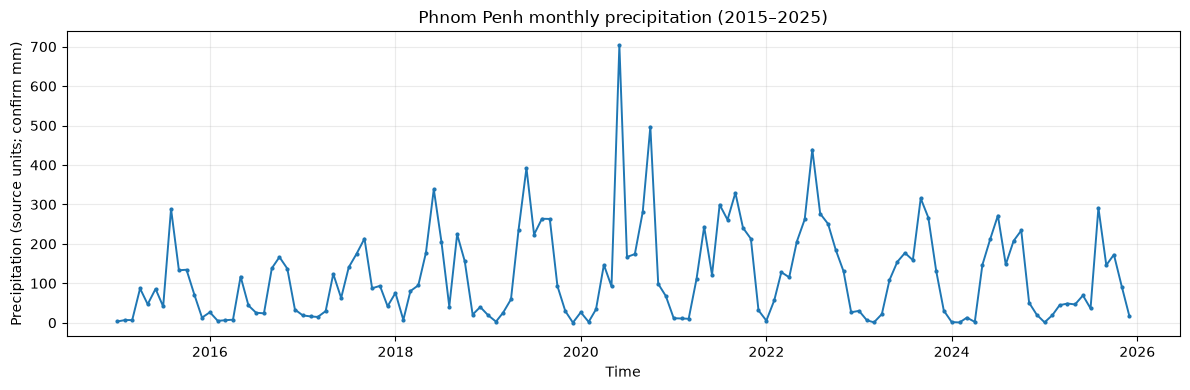

In [3]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(long['date'], long['precipitation'], marker='.', markersize=4, linewidth=1.4)
ax.set(title='Phnom Penh monthly precipitation (2015–2025)', xlabel='Time',
       ylabel='Precipitation (source units; confirm mm)')
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

**My answer — what the time plot shows**

**(a) It repeats every year.** Rain is low from January to March, builds up in April and May, stays heavy from about June to October, then drops in November and December. The May–October months hold 81.9% of all the rain in these 11 years. A wet-season month averages about 195, a dry-season month about 43 — roughly 4.5 times more.

**(b) No clear long-term rise or fall.** 2016 is the lowest year (731.33) and 2020 the highest (2290.55), then it comes back down in 2024 (1309.56) and 2025 (984.51). It goes up and down, not steadily up, so I would not call it a trend.

**(c) One strange point: June 2020 = 703.62.** It is the biggest value in the whole 11 years — about 3 times a normal June. October 2020 is also very high (496.85, the 2nd biggest), so 2020 was a very wet year, not a single typo. I am not guessing why it rained so much; this table cannot say why.

### 3 · Seasonal plot (15 minutes)
A seasonal plot places month on the horizontal axis and draws a separate line for each year, so we can compare the same calendar month across years (FPP §2.4). The data below are *exactly the same observations* as in the time plot.

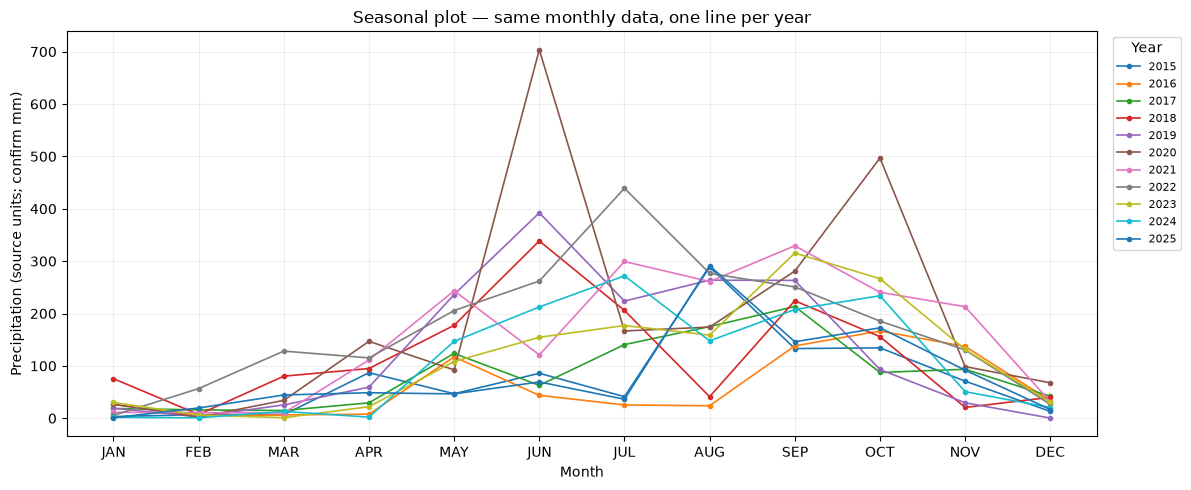

In [4]:
fig, ax = plt.subplots(figsize=(12,5))
for year, part in long.groupby('YEAR', sort=True):
    ax.plot(part['month'], part['precipitation'], marker='.', linewidth=1.2, label=str(year))
ax.set_xticks(range(1,13), MONTHS)
ax.set(title='Seasonal plot — same monthly data, one line per year', xlabel='Month',
       ylabel='Precipitation (source units; confirm mm)')
ax.grid(alpha=.2)
ax.legend(title='Year', bbox_to_anchor=(1.01,1), loc='upper left', ncol=1, fontsize=8)
plt.tight_layout()
plt.show()

**My answer — what the seasonal plot shows**

**(a) September is the wettest on average (about 227) and February the driest (about 12).** The wet part of the year has two bumps — June (about 222) and September (about 227) — with July (about 184) and August (about 191) a little lower in between.

**(b) The shape is the same every year but the height is very different.** June goes from 43.76 (2016) to 703.62 (2020). October goes from 87.40 to 496.85. So the month tells you *when* it rains, not *how much* that year.

**(c) 2015 and 2016 look like opposites.** In 2015 the rain came late: August (288.64) was the wettest month while April, May and June were all under 90. In 2016 August was only 23.91 — drier than most dry-season months — and the wettest month was October (166.56). August 2015 was about 12 times August 2016, back to back. I describe this as late vs weak, without claiming a cause.

### 4 · Seasonal subseries plot (15 minutes)
**Important distinction:** a seasonal subseries plot is **not** just a scatterplot of dots grouped by month. FPP §2.5 arranges each month’s observations across years in its own mini time plot and often draws a horizontal line at that month’s mean. We use the same global vertical axis to help compare months.

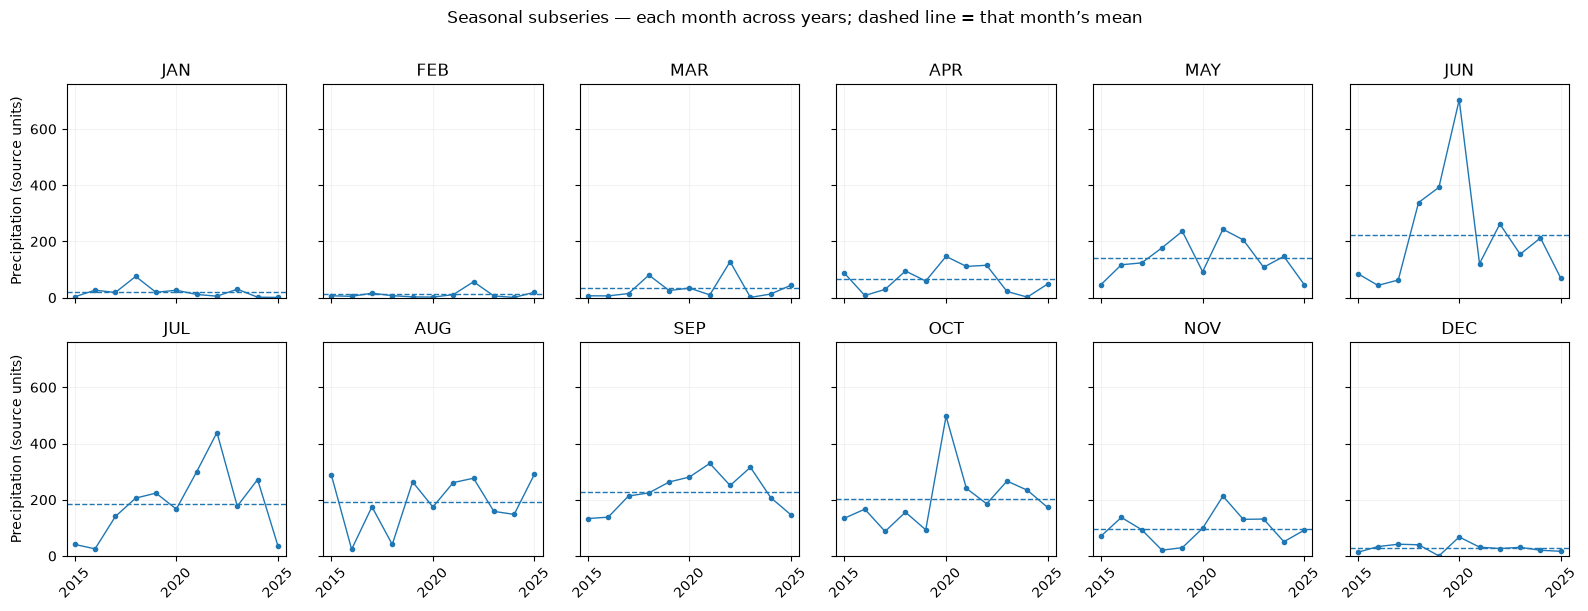

Mean precipitation by calendar month (source units):


,Month,Mean
0,JAN,19.97
1,FEB,12.19
2,MAR,33.17
3,APR,65.90
4,MAY,140.40
5,JUN,222.41
6,JUL,184.29
7,AUG,191.10
8,SEP,227.46
9,OCT,203.04


In [5]:
month_mean = long.groupby('month')['precipitation'].mean()
ymax = long['precipitation'].max()*1.08
fig, axes = plt.subplots(2, 6, figsize=(16,6), sharex=True, sharey=True)
for m, ax in enumerate(axes.flat, start=1):
    part = long[long['month'] == m].sort_values('YEAR')
    ax.plot(part['YEAR'], part['precipitation'], marker='o', markersize=3, linewidth=1)
    ax.axhline(month_mean.loc[m], linestyle='--', linewidth=1, label='Month mean')
    ax.set(title=MONTHS[m-1], xlim=(2014.6, 2025.4), ylim=(0,ymax))
    ax.set_xticks([2015,2020,2025])
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(alpha=.15)
for ax in axes[:,0]: ax.set_ylabel('Precipitation (source units)')
fig.suptitle('Seasonal subseries — each month across years; dashed line = that month’s mean', y=1.01)
plt.tight_layout()
plt.show()
print('Mean precipitation by calendar month (source units):')
display(pd.DataFrame({'Month':MONTHS, 'Mean':month_mean.reindex(range(1,13)).round(2).values}))

**My answer — what the subseries plot shows**

**September is wet and steady** (average about 227, range 133.08 to 329.28). **February is always dry** (average about 12, range 0.80 to 56.69).

June is the hardest month to predict in real amount: it swings from 43.76 to 703.62. February looks jumpy in percent only because its numbers are tiny — in real amount June moves far more.

**The biggest value is June 2020 = 703.62. I do not think it is a mistake**, because (1) it is a normal positive number, not a code like -999, (2) the whole year 2020 is the wettest year (2290.55) with wet neighbours too (April 146.86, October 496.85), and (3) the 12 months of 2020 still add up to NASA's own yearly total exactly. A broken cell would break that sum.

One more strange point: **December 2019 = 0.34**, the smallest value in all 132 months, sitting inside a wet year (2019 is the 4th wettest). It is a real near-zero month, not missing data, because missing data would be -999 and nothing here is negative.

### 5 · Evidence challenge (10 minutes)
Choose one claim. Use a number from the table or a feature visible in a plot as evidence. Seasonal patterns do **not** mean values must be identical every year. An unusual value is not automatically a measurement error.

In [6]:
max_row = long.loc[long['precipitation'].idxmax(), ['date','precipitation']]
print('Largest observed monthly value:',max_row['date'].strftime('%Y-%m'), '=', max_row['precipitation'])
print('Month with highest mean:', MONTHS[int(month_mean.idxmax())-1])
print('Month with lowest mean:', MONTHS[int(month_mean.idxmin())-1])
print('NOTE: these are observations and descriptive summaries, NOT forecasts.')

Largest observed monthly value: 2020-06 = 703.62
Month with highest mean: SEP
Month with lowest mean: FEB
NOTE: these are observations and descriptive summaries, NOT forecasts.


**My answer — short summary**

From 2015 to 2025, almost all rain falls from May to October (81.9% of the total), and September is the wettest month on average. Knowing the month helps a lot, but each year is still very different — the biggest month, June 2020 (703.62), is about 3 times a normal June, and there is no steady rise across the 11 years.

Limits: the file never states the unit, so I cannot call it mm for sure; this is model-estimated data, not a rain gauge; and 11 years is enough to see the yearly cycle but too short to claim anything about climate change. None of this is a forecast.

SERIES  n=132   mean=118.86   sd=117.63   min=0.34   max=703.62
WET  May-Oct   mean= 194.78   share of the 11-year total= 81.9%
DRY  Nov-Apr   mean=  42.94   share of the 11-year total= 18.1%
WET/DRY mean ratio = 4.5x

SEASONAL PROFILE  (n = 11 years per month)


,mean,std,min,max,cv_pct
JAN,19.97,21.32,1.02,75.61,106.77
FEB,12.19,15.85,0.80,56.69,130.02
MAR,33.17,38.94,1.08,128.22,117.39
APR,65.90,48.34,2.15,146.86,73.35
MAY,140.40,68.70,46.49,243.46,48.93
JUN,222.41,197.46,43.76,703.62,88.78
JUL,184.29,125.59,25.41,439.12,68.15
AUG,191.10,95.35,23.91,291.32,49.90
SEP,227.46,68.48,133.08,329.28,30.10
OCT,203.04,112.99,87.40,496.85,55.65


Wettest average month : SEP = 227.46
Driest  average month : FEB = 12.19
Ratio wettest/driest  : 18.7x
Wet-season shape Jun->Sep (one peak or two?): JUN=222.4,  JUL=184.3,  AUG=191.1,  SEP=227.5

ANNUAL TOTALS  (ANN cross-checked against my own sum of the 12 months)


,YEAR,ANN,mean_month,wettest_month,wettest_value
0,2015,917.89,76.49,AUG,288.64
1,2016,731.33,60.94,OCT,166.56
2,2017,1017.36,84.78,SEP,213.37
3,2018,1462.02,121.84,JUN,338.51
4,2019,1608.99,134.08,JUN,392.30
5,2020,2290.55,190.88,JUN,703.62
6,2021,1883.09,156.92,SEP,329.28
7,2022,2082.10,173.51,JUL,439.12
8,2023,1402.29,116.86,SEP,315.42
9,2024,1309.56,109.13,JUL,271.85


Straight-line fit to the 11 annual totals: slope = +48.3 per year,  r = 0.318,  r^2 = 0.101
  -> year explains only 10.1% of the variation in the annual total
  -> minimum 731.33 in 2016   |   maximum 2290.55 in 2020

HOW MUCH OF THE VARIATION IS SEASONAL?
Calendar month alone explains 50.1% of the total variance.
Average error using that month 11-year mean :   54.5
Average error ignoring the season entirely   :   91.9
  -> knowing the calendar month cuts the error by 40.7%

DO TWO YEARS LOOK ALIKE?  (correlation of their 12-month shapes)
Distinct year pairs compared: 55
r ranges from 0.021 to 0.967 -- the least similar pair of years:


,year_A,year_B,r
33,2018,2025,0.021
2,2015,2018,0.087
15,2016,2022,0.158



UNUSUAL OBSERVATIONS  (z = standard deviations above the series mean)


,date,month_name,precipitation,z
65,2020-06-01,JUN,703.62,4.97
69,2020-10-01,OCT,496.85,3.21
90,2022-07-01,JUL,439.12,2.72


,date,month_name,precipitation,z
59,2019-12-01,DEC,0.34,-1.01
109,2024-02-01,FEB,0.80,-1.00
120,2025-01-01,JAN,1.02,-1.00



June 2020 = 703.62
  = 3.16 x the June mean of 222.41
  = 1.79 x the wettest OTHER June, 392.30 in 2019
  = 4.97 standard deviations above the whole-series mean of 118.86
  = 1.60 x the wettest month in any other year (439.12, July 2022)

August 2015 = 288.64  vs  August 2016 = 23.91  ->  12.1 x apart
August 2016 is drier than 75.8% of all 132 months (only 100 months in the whole
  record are wetter than it, and 31 months are drier still, so it ranks 32 lowest).

December 2019 = 0.34  -- the smallest of all 132 observations.
  NASA flags missing data as -999. No value in this table is negative (minimum 0.34),
  so this is a real near-zero month, not a missing-value code.
  Its year 2019 ranks 4th wettest of the 11 on ANN (1608.99).

IS JUNE 2020 AN ERROR?  Evidence that it is NOT:
  1. It is positive and physically plausible for a monsoon month (703.62).
  2. It sits in a coherent wet year rather than contradicting its neighbours:
     2020 ANN = 2290.55 is the highest of the 11 years

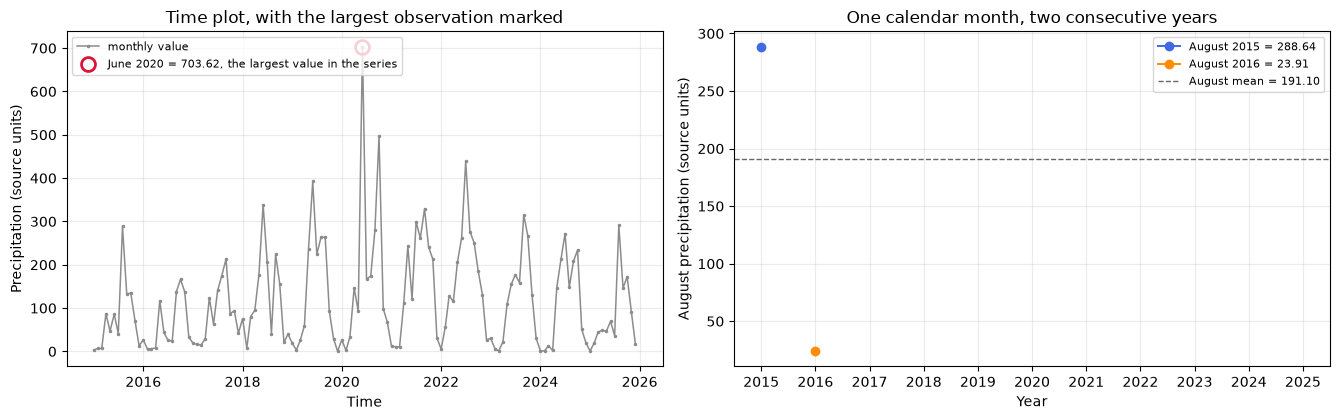

Saved 04_unusual_observations.png to /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework


In [7]:
# ------------------------------------------------------------------------ evidence
# Every number quoted in the written answers is recomputed and printed here, so each
# claim can be checked against the data instead of taken on trust. No new data is
# introduced below -- this cell only reports on the same 132 observations.
scored = long.copy()
s_mean, s_sd = scored['precipitation'].mean(), scored['precipitation'].std(ddof=1)
scored['z'] = (scored['precipitation'] - s_mean) / s_sd

wet = scored[scored['month'].between(5, 10)]
dry = scored[scored['month'].isin([11, 12, 1, 2, 3, 4])]

print('SERIES  n=%d   mean=%.2f   sd=%.2f   min=%.2f   max=%.2f'
      % (len(scored), s_mean, s_sd, scored['precipitation'].min(),
         scored['precipitation'].max()))
print('WET  May-Oct   mean=%7.2f   share of the 11-year total=%5.1f%%'
      % (wet['precipitation'].mean(),
         100 * wet['precipitation'].sum() / scored['precipitation'].sum()))
print('DRY  Nov-Apr   mean=%7.2f   share of the 11-year total=%5.1f%%'
      % (dry['precipitation'].mean(),
         100 * dry['precipitation'].sum() / scored['precipitation'].sum()))
print('WET/DRY mean ratio = %.1fx'
      % (wet['precipitation'].mean() / dry['precipitation'].mean()))

profile = scored.groupby('month')['precipitation'].agg(['mean', 'std', 'min', 'max'])
profile.index = MONTHS
profile['cv_pct'] = 100 * profile['std'] / profile['mean']
print('\nSEASONAL PROFILE  (n = 11 years per month)')
display(profile.round(2))
print('Wettest average month : %s = %.2f' % (profile['mean'].idxmax(),
                                              profile['mean'].max()))
print('Driest  average month : %s = %.2f' % (profile['mean'].idxmin(),
                                              profile['mean'].min()))
print('Ratio wettest/driest  : %.1fx' % (profile['mean'].max() / profile['mean'].min()))
print('Wet-season shape Jun->Sep (one peak or two?):',
      ',  '.join('%s=%.1f' % (m, profile.loc[m, 'mean'])
                 for m in ['JUN', 'JUL', 'AUG', 'SEP']))

# ---- is there a long-term trend in the annual totals?
ann = raw[['YEAR', 'ANN']].copy()
ann['mean_month'] = raw[MONTHS].mean(axis=1).round(2)
ann['wettest_month'] = [MONTHS[int(np.argmax(row))] for row in raw[MONTHS].to_numpy()]
ann['wettest_value'] = raw[MONTHS].max(axis=1).round(2)
print('\nANNUAL TOTALS  (ANN cross-checked against my own sum of the 12 months)')
display(ann)
slope, _ = np.polyfit(ann['YEAR'].astype(float), ann['ANN'].astype(float), 1)
r_ann = np.corrcoef(ann['YEAR'].astype(float), ann['ANN'].astype(float))[0, 1]
print('Straight-line fit to the 11 annual totals: slope = %+.1f per year,  r = %.3f,  r^2 = %.3f'
      % (slope, r_ann, r_ann ** 2))
print('  -> year explains only %.1f%% of the variation in the annual total' % (100 * r_ann ** 2))
print('  -> minimum %.2f in %d   |   maximum %.2f in %d'
      % (ann['ANN'].min(), int(ann.loc[ann['ANN'].idxmin(), 'YEAR']),
         ann['ANN'].max(), int(ann.loc[ann['ANN'].idxmax(), 'YEAR'])))

# ---- how much of the variation is seasonal, and how much is year-specific?
mm = scored.groupby('month')['precipitation'].mean()
resid = scored['precipitation'] - scored['month'].map(mm)
v_between, v_within = mm.var(ddof=1), resid.var(ddof=1)
mae_month, mae_flat = resid.abs().mean(), (scored['precipitation'] - s_mean).abs().mean()
print('\nHOW MUCH OF THE VARIATION IS SEASONAL?')
print('Calendar month alone explains %.1f%% of the total variance.'
      % (100 * v_between / (v_between + v_within)))
print('Average error using that month 11-year mean : %6.1f' % mae_month)
print('Average error ignoring the season entirely   : %6.1f' % mae_flat)
print('  -> knowing the calendar month cuts the error by %.1f%%'
      % (100 * (1 - mae_month / mae_flat)))

wide = scored.pivot(index='YEAR', columns='month', values='precipitation')
corr = wide.T.corr()
offdiag = corr.where(~np.eye(len(corr), dtype=bool))
pairs = pd.DataFrame(
    [(int(a), int(b), float(offdiag.loc[a, b]))
     for i, a in enumerate(offdiag.index) for b in list(offdiag.index)[i + 1:]],
    columns=['year_A', 'year_B', 'r'])
print('\nDO TWO YEARS LOOK ALIKE?  (correlation of their 12-month shapes)')
print('Distinct year pairs compared: %d' % len(pairs))
print('r ranges from %.3f to %.3f -- the least similar pair of years:'
      % (pairs['r'].min(), pairs['r'].max()))
display(pairs.nsmallest(3, 'r').round(3))

# ---- the unusual observations
print('\nUNUSUAL OBSERVATIONS  (z = standard deviations above the series mean)')
_top = scored.nlargest(3, 'precipitation')[['date', 'month_name', 'precipitation', 'z']].copy()
_top['precipitation'] = _top['precipitation'].round(2)
_top['z'] = _top['z'].round(2)
display(_top)
_bot = scored.nsmallest(3, 'precipitation')[['date', 'month_name', 'precipitation', 'z']].copy()
_bot['precipitation'] = _bot['precipitation'].round(2)
_bot['z'] = _bot['z'].round(2)
display(_bot)

jun = scored[scored['month'] == 6].set_index('YEAR')['precipitation']
j20 = jun.loc[2020]
other_jun = jun.drop(2020)
print('\nJune 2020 = %.2f' % j20)
print('  = %.2f x the June mean of %.2f' % (j20 / jun.mean(), jun.mean()))
print('  = %.2f x the wettest OTHER June, %.2f in %d'
      % (j20 / other_jun.max(), other_jun.max(), int(other_jun.idxmax())))
print('  = %.2f standard deviations above the whole-series mean of %.2f'
      % ((j20 - s_mean) / s_sd, s_mean))
print('  = %.2f x the wettest month in any other year (%.2f, July 2022)' % (j20 / 439.12, 439.12))

aug = scored[scored['month'] == 8].set_index('YEAR')['precipitation']
n_drier = int((scored['precipitation'] < aug.loc[2016]).sum())
n_wetter = len(scored) - n_drier - 1
print('\nAugust 2015 = %.2f  vs  August 2016 = %.2f  ->  %.1f x apart'
      % (aug.loc[2015], aug.loc[2016], aug.loc[2015] / aug.loc[2016]))
print('August 2016 is drier than %.1f%% of all 132 months (only %d months in the whole'
      % (100 * n_wetter / len(scored), n_wetter))
print('  record are wetter than it, and %d months are drier still, so it ranks %d lowest).'
      % (n_drier, n_drier + 1))

d19 = float(raw.loc[raw['YEAR'] == 2019, 'DEC'].iloc[0])
ann19 = float(raw.loc[raw['YEAR'] == 2019, 'ANN'].iloc[0])
print('\nDecember 2019 = %.2f  -- the smallest of all 132 observations.' % d19)
print('  NASA flags missing data as -999. No value in this table is negative (minimum %.2f),'
      % scored['precipitation'].min())
print('  so this is a real near-zero month, not a missing-value code.')
print('  Its year 2019 ranks %dth wettest of the 11 on ANN (%.2f).'
      % (int((raw['ANN'] > ann19).sum()) + 1, ann19))

# ---- does the June 2020 value behave like an error?
row2020 = raw[raw['YEAR'] == 2020][MONTHS + ['ANN']].iloc[0]
print('\nIS JUNE 2020 AN ERROR?  Evidence that it is NOT:')
print('  1. It is positive and physically plausible for a monsoon month (%.2f).' % j20)
print('  2. It sits in a coherent wet year rather than contradicting its neighbours:')
print('     2020 ANN = %.2f is the highest of the 11 years; April = %.2f and'
      % (row2020['ANN'], row2020['APR']))
print('     October = %.2f, the 2nd largest value in the entire series.' % row2020['OCT'])
print('  3. The independently supplied ANN column still reconciles:')
print('     my sum of the 12 monthly values of 2020 = %.2f, matching ANN = %.2f, and the'
      % (row2020[MONTHS].sum(), row2020['ANN']))
print('     same check over all 11 years has a largest error of %.2f.'
      % float((raw[MONTHS].sum(axis=1) - raw['ANN']).abs().max()))
print('     A corrupted June would have forced NASA to publish an ANN that disagreed')
print('     with its own monthly columns. It does not.')

# ---- figure 4: the unusual observations, made visible
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 4.3))

axA.plot(long['date'], long['precipitation'], color='0.55', linewidth=1.1,
         marker='.', markersize=3, label='monthly value')
is_jun2020 = (long['date'].dt.year == 2020) & (long['date'].dt.month == 6)
axA.plot(long.loc[is_jun2020, 'date'], long.loc[is_jun2020, 'precipitation'], 'o',
         markersize=10, markerfacecolor='none', markeredgewidth=2, color='crimson',
         label='June 2020 = 703.62, the largest value in the series')
axA.set(title='Time plot, with the largest observation marked',
        xlabel='Time', ylabel='Precipitation (source units)')
axA.legend(fontsize=8, loc='upper left')
axA.grid(alpha=.25)

for year, colour in [(2015, 'royalblue'), (2016, 'darkorange')]:
    part = long[(long['month'] == 8) & (long['YEAR'] == year)]
    axB.plot(part['YEAR'], part['precipitation'], marker='o', color=colour,
             linewidth=1.4,
             label='August %d = %.2f' % (year, part['precipitation'].iloc[0]))
axB.axhline(month_mean.loc[8], linestyle='--', color='0.4', linewidth=1,
            label='August mean = %.2f' % month_mean.loc[8])
axB.set(title='One calendar month, two consecutive years',
        xlabel='Year', ylabel='August precipitation (source units)',
        xlim=(2014.5, 2025.5))
axB.set_xticks(range(2015, 2026))
axB.legend(fontsize=8)
axB.grid(alpha=.25)
plt.tight_layout()
plt.show()

# Save the extra figure next to the other three, using the same output folder rule.
_figdir = COURSEWORK_DIR
if not _figdir.is_absolute() and csv_path is not None:
    _figdir = csv_path.parent / _figdir
_figdir.mkdir(parents=True, exist_ok=True)
fig.savefig(_figdir / '04_unusual_observations.png', dpi=160, bbox_inches='tight')
print('Saved 04_unusual_observations.png to', _figdir)

### 6 · Optional mini-challenge: Which view answers which question? (5 minutes)

**My match**

- **Whole 11 years → time plot.** Only it has time going left to right, so only it can show whether things go up or down over years.
- **July across years → seasonal plot (or the JUL box).** All years are drawn on top of each other by month, so July can be compared directly.
- **Which months are high + how one month changes → two plots.** Which months are high: seasonal plot. How one month changes year by year: subseries plot, where each month gets its own small time plot with its average as a dashed line.

**Still unclear to me:** whether the odd years (2015, 2016, 2020) are real local weather or come from the model. I would need the full NASA file info and a real gauge station to check.

### 7 · Save evidence to your semester project (10 minutes)
Run the cell below. In VS Code this writes the **reshaped copy** of the data and the figures into a `week2_outputs` folder on your own disk — there is nothing to download. Open that folder from the VS Code Explorer, then add those files, this notebook, and a short write-up to your GitHub repository. Keep the original CSV unchanged. Do not upload private data.

Suggested structure: `data/` (with source note), `notebooks/`, `figures/`, `LEARNING_LOG.md`.

In [8]:
# Set OUTPUT_DIR to an absolute path if you want the files somewhere specific.
# A relative path is resolved against the notebook's own folder when the source CSV was
# found there, otherwise against the kernel's working directory (see cell 1).
OUTPUT_DIR = COURSEWORK_DIR

output = OUTPUT_DIR
if not output.is_absolute() and csv_path is not None:
    # Anchor the export next to the source data when the CSV was found.
    output = csv_path.parent / output
output.mkdir(parents=True, exist_ok=True)
long.to_csv(output / 'phnom_penh_monthly_precipitation_2015_2025_long.csv', index=False)

fig1, ax1 = plt.subplots(figsize=(10, 3.5))
ax1.plot(long.date, long.precipitation, linewidth=1.2)
ax1.set(xlabel='Time', ylabel='Precipitation (source units)', title='Time plot')
fig1.tight_layout()
fig1.savefig(output / '01_time_plot.png', dpi=160)
plt.close(fig1)

fig2, ax2 = plt.subplots(figsize=(10, 4))
for year, part in long.groupby('YEAR'):
    ax2.plot(part.month, part.precipitation, linewidth=1, label=str(year))
ax2.set_xticks(range(1, 13), MONTHS)
ax2.set(xlabel='Month', ylabel='Precipitation (source units)', title='Seasonal plot')
ax2.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
fig2.tight_layout()
fig2.savefig(output / '02_seasonal_plot.png', dpi=160, bbox_inches='tight')
plt.close(fig2)

fig3, axs = plt.subplots(2, 6, figsize=(16, 6), sharex=True, sharey=True)
for m, ax in enumerate(axs.flat, 1):
    part = long[long.month == m]
    ax.plot(part.YEAR, part.precipitation, marker='.', linewidth=1)
    ax.axhline(month_mean.loc[m], linestyle='--', linewidth=1)
    ax.set(title=MONTHS[m - 1], xlim=(2014.6, 2025.4), ylim=(0, ymax))
    ax.set_xticks([2015, 2020, 2025])
    ax.tick_params(axis='x', labelrotation=45)
fig3.suptitle('Seasonal subseries plot')
fig3.tight_layout()
fig3.savefig(output / '03_seasonal_subseries_plot.png', dpi=160, bbox_inches='tight')
plt.close(fig3)

# In VS Code the files are simply on disk: open them from the Explorer on the left.
print('Files written to:')
for p in sorted(output.iterdir()):
    print('   ', p, f'({p.stat().st_size:,} bytes)')
print()
print('Add that folder to your GitHub repository, keep the original CSV unchanged.')

Files written to:
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/01_time_plot.png (85,440 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/02_seasonal_plot.png (182,914 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/03_seasonal_subseries_plot.png (151,655 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/04_unusual_observations.png (145,527 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/WEEK1 (442 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/WEEK2 (440 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYSIS )/coursework/WEEK3 (686 bytes)
    /home/chenla/Documents/Obsidian Vault/Y3 - SEMESTER 1/TSA ( TIME SERIES ANALYS

### Submission checklist
- [ ] All notebook cells run without errors.
- [ ] Answer cells 1–5 contain **your own** evidence-based explanations.
- [ ] Include all three plots in your GitHub `figures/` folder.
- [ ] Keep the original CSV or source citation and explain that the downloaded table lacks NASA metadata.
- [ ] Put the notebook under `notebooks/` and update `LEARNING_LOG.md`.
- [ ] Share **one GitHub link** (and one annotated graph in your Miro group frame).

**Exit ticket:** What is the difference between a seasonal plot and seasonal subseries plot? What remains unclear?

**Next week:** lag relationships / autocorrelation — today’s plots are exploration, not evidence that a forecast will be accurate.

### Findings summary

| What the teacher asked | My finding |
|---|---|
| Time index / target / frequency | One value per month, Jan 2015 – Dec 2025, 132 months, target = monthly rain |
| Missing data | None — no gaps, no duplicates |
| Time plot | Same cycle every year; 81.9% of rain in May–Oct; no steady trend |
| Seasonal plot | September wettest, February driest; same shape, very different heights |
| Subseries plot | September steady and wet; June swings the most (44 to 704) |
| Unusual observation | **June 2020 = 703.62**, the biggest value, probably real, not a typo |

---

# Week 3 — Lag Relationships and Autocorrelation

*Added below my completed Week 2 work, as instructed. Week 2 is unchanged above.*

**Week 3 question:** Are current precipitation values related to past precipitation values?

**Dataset:** Phnom Penh Monthly Rainfall, 2015–2025 (132 monthly observations, zero missing values)

# TSA Week 3 — Lag Relationships and Autocorrelation

## Week 3 Extension to Your Week 2 Notebook

**Important:** This is **not a new analysis from the beginning**.

You already completed Week 2 using the Phnom Penh Monthly Rainfall dataset.

For Week 3:

1. Open your completed **Week 2 notebook**.
2. Make a copy and rename it, for example:  
   `TSA_Week3_YourName.ipynb`
3. Add the Week 3 cells below your Week 2 work.
4. Run your Week 2 cells first.
5. Complete **Answers 6–9** below.

### Week 3 question

> **Are current precipitation values related to past precipitation values?**

### Learning goals

By the end of this activity, you should be able to:

- explain what a **lag** means;
- create **Lag-1** and **Lag-12** values;
- interpret lag plots;
- create and interpret an **ACF plot**;
- use evidence from plots and numerical results to describe time dependence.

**Dataset:** Phnom Penh Monthly Rainfall, 2015–2025  
**Continue using:** the Week 2 dataframe `long`


## 1. Check that Week 2 is ready

Run this cell after your Week 2 cells.

Your Week 2 dataframe should already be called `long` and contain a `date` column and a `precipitation` column.


In [9]:
# Week 3 starts from your completed Week 2 notebook.

required_columns = {"date", "precipitation"}

if "long" not in globals():
    raise NameError(
        "Week 3 must be added below your completed Week 2 notebook. "
        "Run your Week 2 cells first so the dataframe `long` exists."
    )

missing = required_columns - set(long.columns)

if missing:
    raise ValueError(
        f"Your Week 2 dataframe `long` is missing these columns: {sorted(missing)}"
    )

print("Week 2 data found. You are ready for Week 3.")
display(long.head())


Week 2 data found. You are ready for Week 3.


,date,YEAR,month,month_name,precipitation
0,2015-01-01,2015,1,JAN,3.26
1,2015-02-01,2015,2,FEB,6.85
2,2015-03-01,2015,3,MAR,6.79
3,2015-04-01,2015,4,APR,86.97
4,2015-05-01,2015,5,MAY,46.84


## 2. Create Lag-1 and Lag-12

A **lag** means looking backward in time.

For this monthly precipitation series:

- **Lag 1** = precipitation **1 month earlier**
- **Lag 12** = precipitation **12 months earlier**, or the same month one year earlier

Run the code and inspect the first rows.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Reuse the cleaned Week 2 data
lag_data = long[["date", "precipitation"]].copy()

# Ensure correct chronological order
lag_data["date"] = pd.to_datetime(lag_data["date"])
lag_data = lag_data.sort_values("date").set_index("date")

# Create lagged values
lag_data["lag_1"] = lag_data["precipitation"].shift(1)
lag_data["lag_12"] = lag_data["precipitation"].shift(12)

display(lag_data.head(15))


,precipitation,lag_1,lag_12
date,,,
2015-01-01,3.26,NaN,NaN
2015-02-01,6.85,3.26,NaN
2015-03-01,6.79,6.85,NaN
2015-04-01,86.97,6.79,NaN
2015-05-01,46.84,86.97,NaN
2015-06-01,85.88,46.84,NaN
2015-07-01,41.22,85.88,NaN
2015-08-01,288.64,41.22,NaN
2015-09-01,133.08,288.64,NaN


### Answer 6 — Understand the lag values

**a. What does Lag-1 mean in this dataset?**
Lag-1 is the rainfall from the month immediately before.

**b. What does Lag-12 mean in this dataset?**
Lag-12 is the rainfall from twelve months earlier, which on monthly data is the same month one year ago.

**c. Why is the first Lag-1 value blank (NaN), and why are the first 12 Lag-12 values blank?**
`shift(k)` pushes values down k rows, and the first row has nothing above it to push down into. So lag-1 loses 1 value and lag-12 loses 12.

**d. Are these blank values automatically data errors? Explain.**
No, they are a boundary effect rather than missing data. My precipitation column holds all 132 values, and dropping the blanks still leaves 131 valid pairs at lag-1 and 120 at lag-12.

## 3. Create the Lag-1 Plot

The Lag-1 plot compares:

- **x-axis:** precipitation one month earlier
- **y-axis:** current precipitation

Each point represents two observations separated by one month.


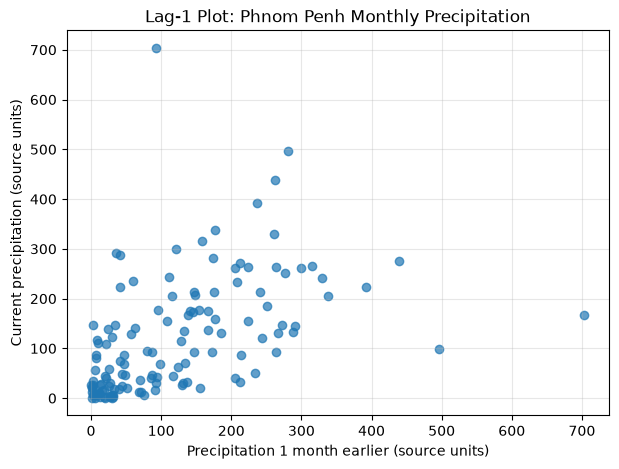

In [11]:
lag1 = lag_data[["lag_1", "precipitation"]].dropna()

plt.figure(figsize=(7, 5))
plt.scatter(lag1["lag_1"], lag1["precipitation"], alpha=0.7)

plt.xlabel("Precipitation 1 month earlier (source units)")
plt.ylabel("Current precipitation (source units)")
plt.title("Lag-1 Plot: Phnom Penh Monthly Precipitation")
plt.grid(True, alpha=0.3)

plt.show()


## 4. Create the Lag-12 Plot

Because the data are monthly, Lag-12 compares the current month with the **same calendar month one year earlier**.


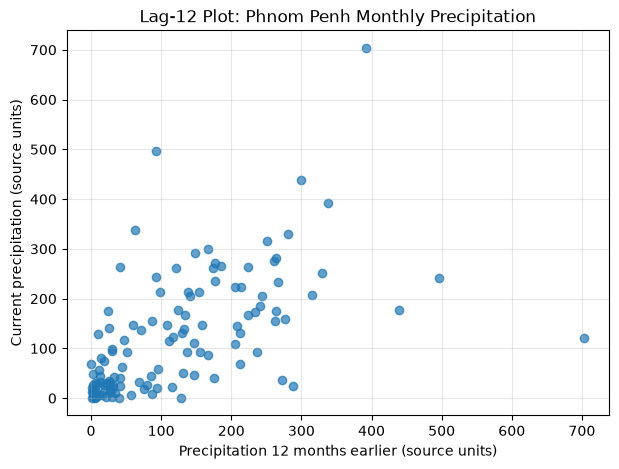

In [12]:
lag12 = lag_data[["lag_12", "precipitation"]].dropna()

plt.figure(figsize=(7, 5))
plt.scatter(lag12["lag_12"], lag12["precipitation"], alpha=0.7)

plt.xlabel("Precipitation 12 months earlier (source units)")
plt.ylabel("Current precipitation (source units)")
plt.title("Lag-12 Plot: Phnom Penh Monthly Precipitation")
plt.grid(True, alpha=0.3)

plt.show()


### Answer 7 — Compare Lag-1 and Lag-12

**a. Which plot appears to show a clearer relationship: Lag-1 or Lag-12?**
Lag-12, at r = 0.567 against 0.492 for lag-1.

**b. What visual evidence supports your answer?**
The two scatters look more alike than I expected, since both are dense clusters near the origin, but the lag-12 cloud rises more consistently and the correlation values are the clearest evidence.

**c. Why might Lag-12 be especially interesting for monthly precipitation data?**
It lands on the same calendar month one year earlier, so it removes short-term weather noise and isolates the annual cycle.

**d. Does a visible relationship prove that precipitation 12 months ago causes precipitation today? Explain.**
No. Both values are rainfall under the same monsoon, so a shared seasonal driver explains the link; it does not mean last year caused this year.

## 5. Autocorrelation Function (ACF)

The lag plots above investigate selected lags.

The **ACF** lets us examine the correlation between the series and many of its past values at once.

For monthly data:

- Lag 1 = 1 month earlier
- Lag 6 = 6 months earlier
- Lag 12 = 1 year earlier
- Lag 24 = 2 years earlier

The shaded region provides approximate reference bounds.


<Figure size 1000x500 with 0 Axes>

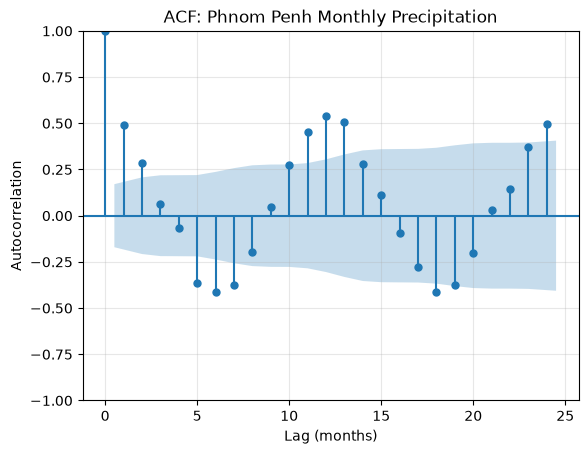

In [13]:
series = lag_data["precipitation"].dropna()

plt.figure(figsize=(10, 5))

plot_acf(
    series,
    lags=24,
    alpha=0.05
)

plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.title("ACF: Phnom Penh Monthly Precipitation")
plt.grid(True, alpha=0.3)

plt.show()


### Answer 8 — Interpret the ACF

**a. Excluding Lag 0, which positive lag has the largest autocorrelation?**
Lag 12, at about 0.54.

**b. What do you notice at or around Lag 12?**
A clear positive spike just outside the shaded band, and the pattern repeats at multiples of twelve, with lag 23 at 0.37 and lag 24 at 0.50, which is the signature of a yearly cycle.

**c. Which bars, if any, extend beyond the shaded reference region?**
Lags 1, 2, 5-8, 10-14, 17-20, 23 and 24 all fall outside the ±0.171 band, and the negative bars at 5-8, which reach −0.42, matter as much as the positive ones.

**d. What does the ACF suggest about time dependence in this precipitation series?**
It shows real time dependence rather than noise: rainfall is positively related to the same month a year ago and negatively related to months five to eight months away, which is the wet and dry halves of the year sitting opposite each other.

## 6. Check Selected Autocorrelation Values

Use numerical values to support your visual interpretation.

The numbers are evidence to support your explanation; they do not replace the plots.


In [14]:
selected_lags = [1, 2, 3, 6, 12, 18, 24]

acf_values = pd.DataFrame({
    "lag_months": selected_lags,
    "autocorrelation": [
        series.autocorr(lag=lag) for lag in selected_lags
    ]
})

display(acf_values.round(3))


,lag_months,autocorrelation
0,1,0.492
1,2,0.290
2,3,0.065
3,6,-0.427
4,12,0.567
5,18,-0.451
6,24,0.556


### Answer 9 — Week 3 Conclusion

Lag-12 is the stronger comparison, 0.567 against 0.492, so the annual cycle matters more than the previous month. The ACF agrees: lag 12 is the largest positive autocorrelation at about 0.54 and the pattern repeats every twelve months, while lags 5-8 sit at about −0.42. So the series shows real time dependence rather than noise. Next I would check whether the lag-12 relationship holds in every individual year, because June 2020 at 703.62 is far outside a typical June.

---

# Week 3 Submission Checklist

Before submitting your updated notebook:

- [ ] I kept my completed Week 2 work.
- [ ] I added the Week 3 section below Week 2.
- [ ] Lag-1 values are shown.
- [ ] Lag-12 values are shown.
- [ ] The Lag-1 plot is visible.
- [ ] The Lag-12 plot is visible.
- [ ] The ACF plot up to 24 lags is visible.
- [ ] I answered Questions 6–9 in my own words.
- [ ] My answers use evidence from the plots/results.
- [ ] I did not claim that correlation automatically means causation.
- [ ] All cells run without errors.

### What to submit

Submit **one updated `.ipynb` file** containing:

**your completed Week 2 work + this new Week 3 extension**

Suggested filename:

`TSA_Week3_YourName.ipynb`

### Exit Ticket

In **one sentence**:

> What is the difference between a **lag plot** and an **ACF plot**?


---

# Week 4 — Is the Series Stable?

*Added below my completed Week 2–3 work, as instructed. Week 2 and Week 3 are unchanged above. The Week 4 section is the teacher's Week 4 starter with my answers filled in.*

**Week 4 question:** Does the statistical behaviour of this series remain reasonably stable through time?

# TSA — Week 4 Python Lab: Stationarity Investigation
## Phnom Penh monthly precipitation (2015–2025)

**Student:** Heng Hour  |  **Group:** 9  |  **GitHub repository:** https://github.com/hengXiaoHour/tsa-course

**Main question:** Does the statistical behaviour of the series appear stable through time?

**Connection:** Week 2 made time and seasonal plots using `long['date']` and `long['precipitation']`. Week 3 explored lags and autocorrelation. In Week 4, reuse both ideas to investigate stationarity.

**Learning focus:** inspect stability of level and variation, compare earlier/later windows, revisit the ACF, contrast white noise and a stationary dependent series with a random walk, and write an evidence-based judgement.

**Scope:** This is a visual and descriptive investigation, **not a formal stationarity test**. ADF, KPSS, PACF, differencing and ARIMA are not required here.

**Textbook basis:** Shumway & Stoffer, *Time Series Analysis and Its Applications*, 5th ed., §§1.3–1.5; Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, §2.8 (ACF). Python demonstrations and the local dataset are classroom adaptations.

**Data-source caution:** The included table is the same exact numeric table used in Week 2. The available copy does not contain the complete NASA POWER metadata or a confirmed unit. Plots therefore say **source units (confirm mm)**; do not claim gauge measurements or verified physical units without consulting the original download metadata.

## Before you start — use Week 2 names

Across these labs we keep **`long`** as the working DataFrame, **`date`** as the time index column, and **`precipitation`** as the target column. No `df`/`precip` renaming is needed.

This notebook can run independently in Google Colab. The next cell creates `long` using **the same source table and wide-to-long transformation as Week 2**, but only when `long` is not already present. If you run Week 4 after Week 2–3 in the same runtime, your existing `long` is reused.

If you are using the **Week 2 exported CSV** in a new runtime instead of the embedded source table, you can load it with `long = pd.read_csv('phnom_penh_monthly_precipitation_2015_2025_long.csv')` after uploading it to Colab; then skip the embedded-data creation. The validation cell below checks either route.


In [15]:
# Prepare the Week 2 `long` DataFrame when this notebook is opened on its own.
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# This is exactly the table used in the Week 2 notebook; ANN is not an extra month.
RAW_CSV = 'YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN\n2015,3.26,6.85,6.79,86.97,46.84,85.88,41.22,288.64,133.08,134.41,70.89,13.06,917.89\n2016,26.66,4.83,6.41,7.81,117.14,43.76,25.41,23.91,138.2,166.56,137.19,33.45,731.33\n2017,18.64,16.04,14.73,29.46,123.78,62.85,140.62,175,213.37,87.4,93.56,41.91,1017.36\n2018,75.61,7.22,80.34,94.97,177.46,338.51,205.87,41.17,224.33,155.88,20.71,39.95,1462.02\n2019,19.07,2.88,25.55,59.37,236.16,392.3,223.72,263.68,263.18,93.11,29.63,0.34,1608.99\n2020,26.58,2.14,34.14,146.86,92.3,703.62,166.68,174.17,280.88,496.85,98.6,67.73,2290.55\n2021,11.54,10.8,10.14,111.31,243.46,121.11,299.33,261.06,329.28,240.56,213,31.5,1883.09\n2022,5.36,56.69,128.22,115.23,205.65,262.05,439.12,276.57,250.76,185.5,130.42,26.53,2082.1\n2023,30.18,6.23,1.08,22.04,108.3,154.58,177.06,158.74,315.42,266.52,131.32,30.82,1402.29\n2024,1.75,0.8,13.03,2.15,146.8,212.52,271.85,147.87,207.61,233.95,50.78,20.45,1309.56\n2025,1.02,19.62,44.45,48.73,46.49,69.32,36.31,291.32,146,172.7,91.83,16.72,984.51'

if 'long' in globals() and isinstance(long, pd.DataFrame):
    print('Using the existing Week 2–3 DataFrame: long')
else:
    raw = pd.read_csv(io.StringIO(RAW_CSV))
    MONTHS = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
    long = raw.melt(id_vars=['YEAR'], value_vars=MONTHS,
                    var_name='month_name', value_name='precipitation')
    long['month'] = long['month_name'].map({name:i for i,name in enumerate(MONTHS,1)})
    long['date'] = pd.to_datetime(dict(year=long['YEAR'],month=long['month'],day=1))
    long = long[['date','YEAR','month','month_name','precipitation']].sort_values('date').reset_index(drop=True)
    long['precipitation'] = pd.to_numeric(long['precipitation'],errors='coerce')
    long.loc[long['precipitation'] <= -900, 'precipitation'] = np.nan
    print('Recreated Week 2 `long` from the same embedded source data.')

display(long.head())


Using the existing Week 2–3 DataFrame: long


,date,YEAR,month,month_name,precipitation
0,2015-01-01,2015,1,JAN,3.26
1,2015-02-01,2015,2,FEB,6.85
2,2015-03-01,2015,3,MAR,6.79
3,2015-04-01,2015,4,APR,86.97
4,2015-05-01,2015,5,MAY,46.84


In [16]:
# Week 4 — imports (already loaded above)
# Keep `long['date']` and `long['precipitation']` from Week 2.


## 1. Predict first

Before running the stationarity analysis, answer:

**Do you think the rainfall series is:**
- Stationary-looking
- Not stationary-looking
- Unsure

Explain your prediction in **1–2 sentences**.

**My prediction:** **Not stationary-looking.** From Week 2 the seasonal cycle is very strong (February averages 12.19 while September averages 227.46), so the typical level depends on the calendar month, which already violates the constant-mean requirement.

In [17]:
# Check the Week 2–3 dataframe without silently removing months.
required = {'date', 'precipitation'}
missing_columns = required - set(long.columns)
if missing_columns:
    raise ValueError(f'Missing columns: {sorted(missing_columns)}. Use the Week 2 `long` dataframe.')

long = long.copy()
long['date'] = pd.to_datetime(long['date'], errors='coerce')
long['precipitation'] = pd.to_numeric(long['precipitation'], errors='coerce')
long = long.sort_values('date').reset_index(drop=True)

if long['date'].isna().any():
    raise ValueError('Invalid dates found. Investigate before analysis.')
if long['date'].duplicated().any():
    raise ValueError('Duplicate months found. Investigate before analysis.')
if long['precipitation'].isna().any():
    raise ValueError('Missing precipitation values found. Investigate; do not silently drop months.')

expected = pd.date_range(long['date'].min(), long['date'].max(), freq='MS')
missing_months = expected.difference(pd.DatetimeIndex(long['date']))
if len(missing_months):
    raise ValueError(f'Missing monthly dates: {list(missing_months.strftime("%Y-%m"))}')
if len(long) != len(expected):
    raise ValueError('Expected one observation for each month.')

print('Observations:', len(long))
print('Start:',long['date'].min().date(),'End:',long['date'].max().date())
print('Missing values:',long['precipitation'].isna().sum(), '| Missing months:', len(missing_months))
display(long[['date','precipitation']].head())


Observations: 132
Start: 2015-01-01 End: 2025-12-01
Missing values: 0 | Missing months: 0


,date,precipitation
0,2015-01-01,3.26
1,2015-02-01,6.85
2,2015-03-01,6.79
3,2015-04-01,86.97
4,2015-05-01,46.84


## 2. Inspect the full time plot

Look for visual evidence:

1. Does the typical level appear similar through time?
2. Does the variability appear similar through time?
3. Is there a clear long-term trend?
4. Is there a persistent change or shift?
5. What seasonal behaviour do you notice?

Remember: a time plot provides **visual evidence**, not formal proof of stationarity.


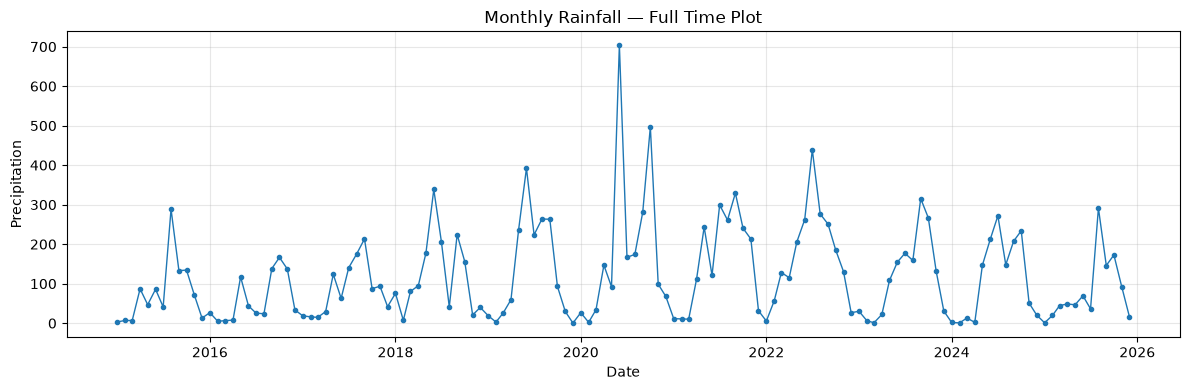

In [18]:
plt.figure(figsize=(12, 4))

plt.plot(
    long['date'],
    long['precipitation'],
    marker='o',
    markersize=3,
    linewidth=1
)

plt.title('Monthly Rainfall — Full Time Plot')
plt.xlabel('Date')
plt.ylabel('Precipitation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### My observations

1. **The typical level is not stable through time.** Every year repeats the same dry-to-wet swing, and yearly means range from 60.9 (2016) to 190.9 (2020); June 2020 reaches 703.62, far above any other month.
2. **Variability stays in the same order of magnitude but is not constant.** The early window has sd 68.70 versus 96.22 late, and the 2020 spike stretches the vertical scale well beyond the early years.
3. **No steady long-term trend, but clear seasonal behaviour.** Annual totals fit a slope of +48.3 per year yet year explains only about 10% of their variation (r = 0.318), with totals rising to 2020 then falling back to 984.51 in 2025; the repeating pattern is dry January–March, wet June–October with a September peak.

## 3. Compare two windows in time

We compare the **first 36 observations** and the **last 36 observations**.

For monthly data, this is approximately three years in each window.

Ask:
- Is the typical level similar?
- Is the variability similar?
- Does the overall behaviour look similar?


In [19]:
window_size = 36

if len(long) < window_size * 2:
    raise ValueError(
        f"This activity needs at least {window_size * 2} observations. "
        f"Current dataset has {len(long)}."
    )

early = long.iloc[:window_size].copy()
late = long.iloc[-window_size:].copy()

print("Earlier period:")
print(early['date'].min(), "to", early['date'].max())

print("\nLater period:")
print(late['date'].min(), "to", late['date'].max())


Earlier period:
2015-01-01 00:00:00 to 2017-12-01 00:00:00

Later period:
2023-01-01 00:00:00 to 2025-12-01 00:00:00


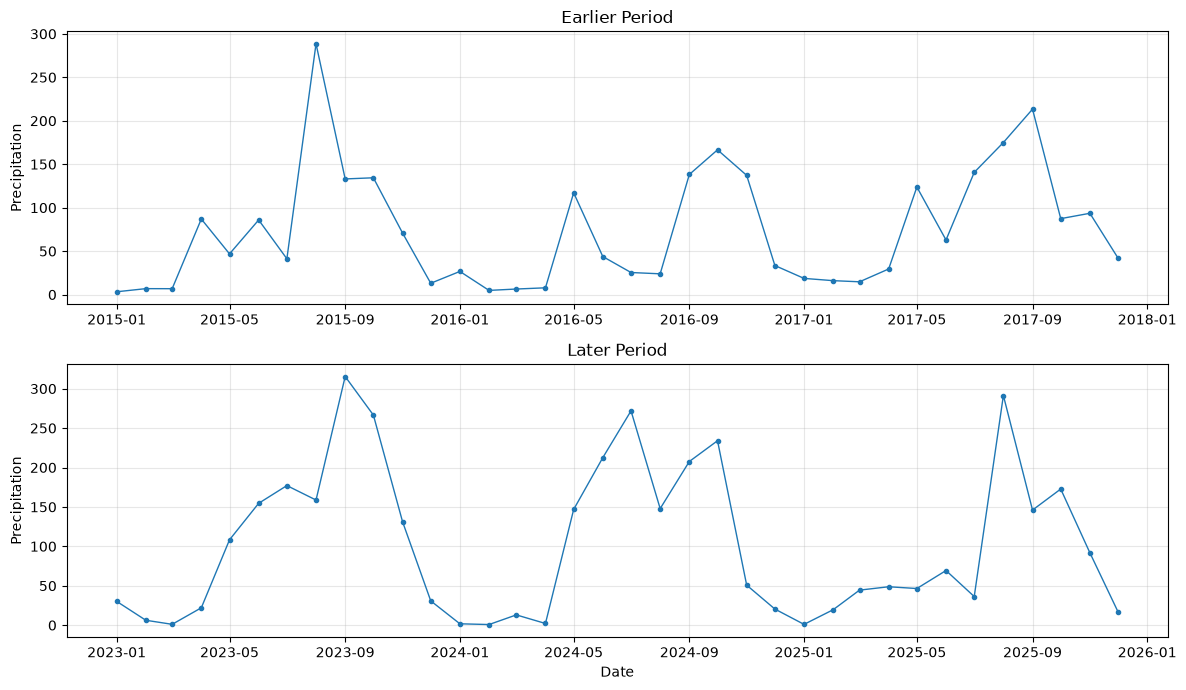

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(
    early['date'],
    early['precipitation'],
    marker='o',
    markersize=3,
    linewidth=1
)
axes[0].set_title('Earlier Period')
axes[0].set_ylabel('Precipitation')
axes[0].grid(alpha=0.3)

axes[1].plot(
    late['date'],
    late['precipitation'],
    marker='o',
    markersize=3,
    linewidth=1
)
axes[1].set_title('Later Period')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Precipitation')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:
# Descriptive evidence — NOT a formal stationarity test

comparison = pd.DataFrame({
    'Period': ['Earlier', 'Later'],
    'Mean': [
        early['precipitation'].mean(),
        late['precipitation'].mean()
    ],
    'Standard deviation': [
        early['precipitation'].std(),
        late['precipitation'].std()
    ],
    'Minimum': [
        early['precipitation'].min(),
        late['precipitation'].min()
    ],
    'Maximum': [
        early['precipitation'].max(),
        late['precipitation'].max()
    ]
})

display(comparison.round(2))


,Period,Mean,Standard deviation,Minimum,Maximum
0,Earlier,74.07,68.70,3.26,288.64
1,Later,102.68,96.22,0.80,315.42


### Compare the two periods

| Evidence | Earlier period | Later period | Similar? |
|---|---|---|---|
| Typical level | Mean 74.07 (Jan 2015–Dec 2017) | Mean 102.68 (Jan 2023–Dec 2025) | No — later sits about 28.6 higher |
| Variability | sd 68.70, range 3.26–288.64 | sd 96.22, range 0.80–315.42 | No — later spreads wider |
| Overall behaviour | Dry start, wet middle, autumn peak, each year | Same seasonal shape, each year | Broadly similar shape, different level |

**Question:** Do these two periods appear to follow reasonably similar statistical behaviour?

**My answer:** No. The seasonal shape repeats in both windows, but the typical level (74.07 against 102.68) and the spread (sd 68.70 against 96.22) both moved, so the statistical behaviour is not reasonably similar.

## 4. Revisit the Week 3 ACF

Week 3 asked:

> **Is the present related to the past?**

Week 4 asks:

> **Does the dependence behaviour appear reasonably stable through time?**


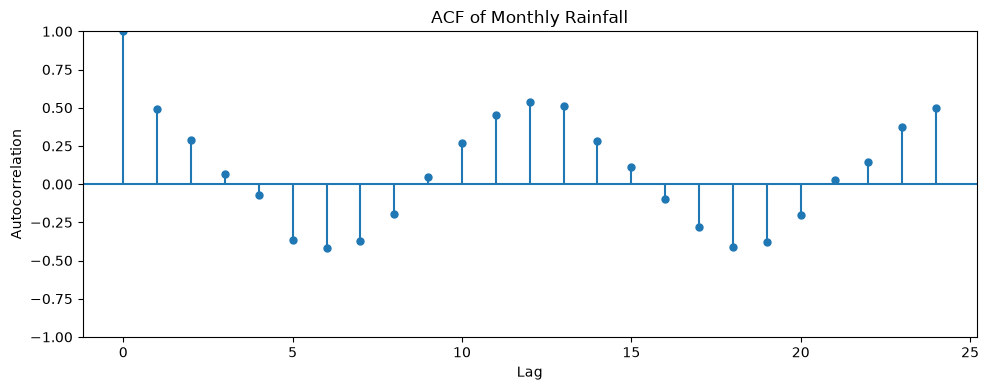

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(
    long['precipitation'],
    lags=min(24, len(long) // 2 - 1),
    alpha=None,   # keep confidence bands out at this stage
    ax=ax
)

ax.set_title('ACF of Monthly Rainfall')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()


### Full-series ACF questions

1. What happens at lag 1?
2. What happens around lag 12 (one year for monthly data)?
3. What does the ACF suggest about dependence across time?
4. Does this ACF by itself prove stationarity? Why or why not?

**My interpretation:** Lag 1 is clearly positive (0.492 on overlapping pairs), so consecutive months carry information about each other. Lag 12 is the strongest positive autocorrelation (about 0.54 on the plot, 0.567 on pairs) with the pattern repeating at lag 24, so the series shows real dependence, including an annual cycle. This ACF by itself does **not** prove stationarity: the lecture's stationary dependent example also has nonzero ACF, so dependence and stability are separate questions — the ACF answers whether the past matters, not whether the behaviour stays the same.

## 5. Compare ACF: earlier vs later period

This is a practical visual comparison.

Different sample ACF values are expected. We are looking for **broadly similar or clearly different dependence behaviour**, not exact equality.


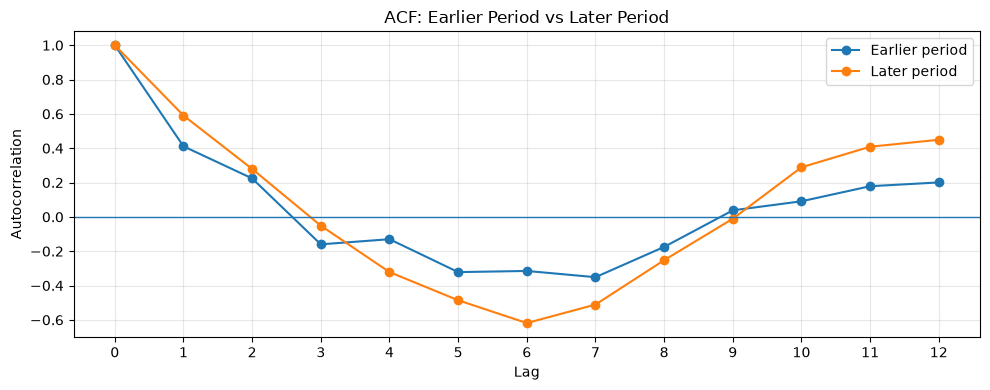

In [23]:
max_lag = min(12, len(early) // 2 - 1, len(late) // 2 - 1)

acf_early = acf(
    early['precipitation'],
    nlags=max_lag,
    fft=False
)

acf_late = acf(
    late['precipitation'],
    nlags=max_lag,
    fft=False
)

lags = np.arange(max_lag + 1)

plt.figure(figsize=(10, 4))

plt.plot(lags, acf_early, marker='o', label='Earlier period')
plt.plot(lags, acf_late, marker='o', label='Later period')

plt.axhline(0, linewidth=1)
plt.title('ACF: Earlier Period vs Later Period')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.xticks(lags)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Dependence through time

1. Are the two ACF patterns reasonably similar?
2. What happens around lag 1?
3. What happens around lag 12?
4. Does the dependence behaviour appear similar in both periods?

**My interpretation:** Yes, broadly similar. Both windows show positive lag 1 (0.41 early, 0.59 late), a mid-lag dip into negative values, and a rise at lag 12 (0.20 early, 0.45 late). The magnitudes differ, which is expected with only 36 observations per window and a wider late spread, but the shape matches — so the dependence behaviour looks reasonably similar even though the level does not.

# Activity — Stationarity Detective

Before returning to the rainfall data, compare three known examples.

You will see:

- **Series A**
- **Series B**
- **Series C**

Do **not** reveal their identities until after making your judgement.


In [24]:
np.random.seed(42)

n = 150

# A: white noise
series_A = np.random.normal(0, 1, n)

# B: stationary dependent process
# A simple three-point moving-average-style construction.
noise = np.random.normal(0, 1, n + 2)
series_B = (
    noise[:-2] +
    noise[1:-1] +
    noise[2:]
) / 3

# C: random walk
series_C = np.cumsum(
    np.random.normal(0, 1, n)
)

series_dict = {
    'Series A': series_A,
    'Series B': series_B,
    'Series C': series_C
}


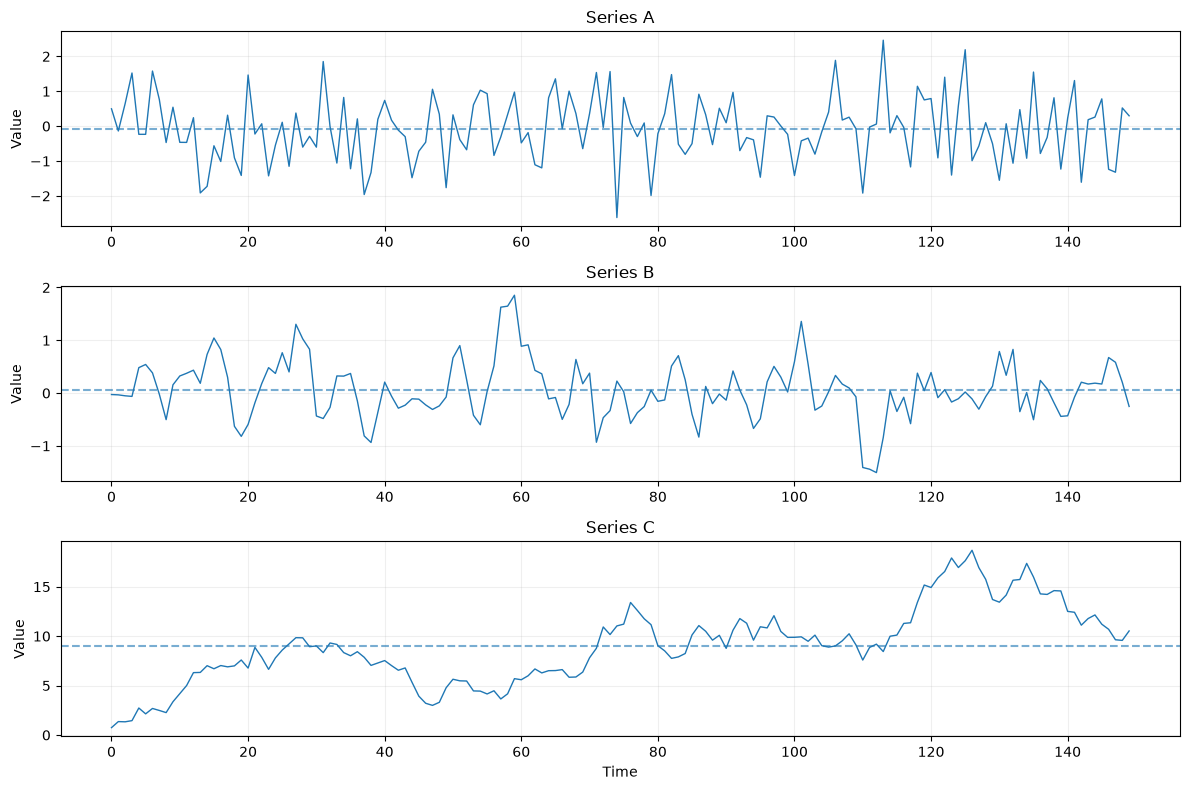

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for ax, (name, values) in zip(axes, series_dict.items()):
    ax.plot(values, linewidth=1)
    ax.axhline(values.mean(), linestyle='--', alpha=0.6)
    ax.set_title(name)
    ax.set_ylabel('Value')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time')

plt.tight_layout()
plt.show()


## 6. Decide before seeing the ACF

For each series choose:

**Stationary-looking / Not stationary-looking / Unsure**

### Series A
**Decision:** Stationary-looking

**Evidence:** Fluctuates around a stable mean of -0.08 (sd 0.94), with the first half averaging -0.115 and the second -0.050 — no drift, no widening.

### Series B
**Decision:** Stationary-looking

**Evidence:** Stable mean of 0.06 with halves at 0.163 and -0.034, but visibly smoother short wiggles than A, so nearby values share information (dependence, still stationary).

### Series C
**Decision:** Not stationary-looking

**Evidence:** Wanders from 0.75 up to 18.69 instead of fluctuating around one level; the first half averages 6.16 but the second 11.82 — the level moves through time.

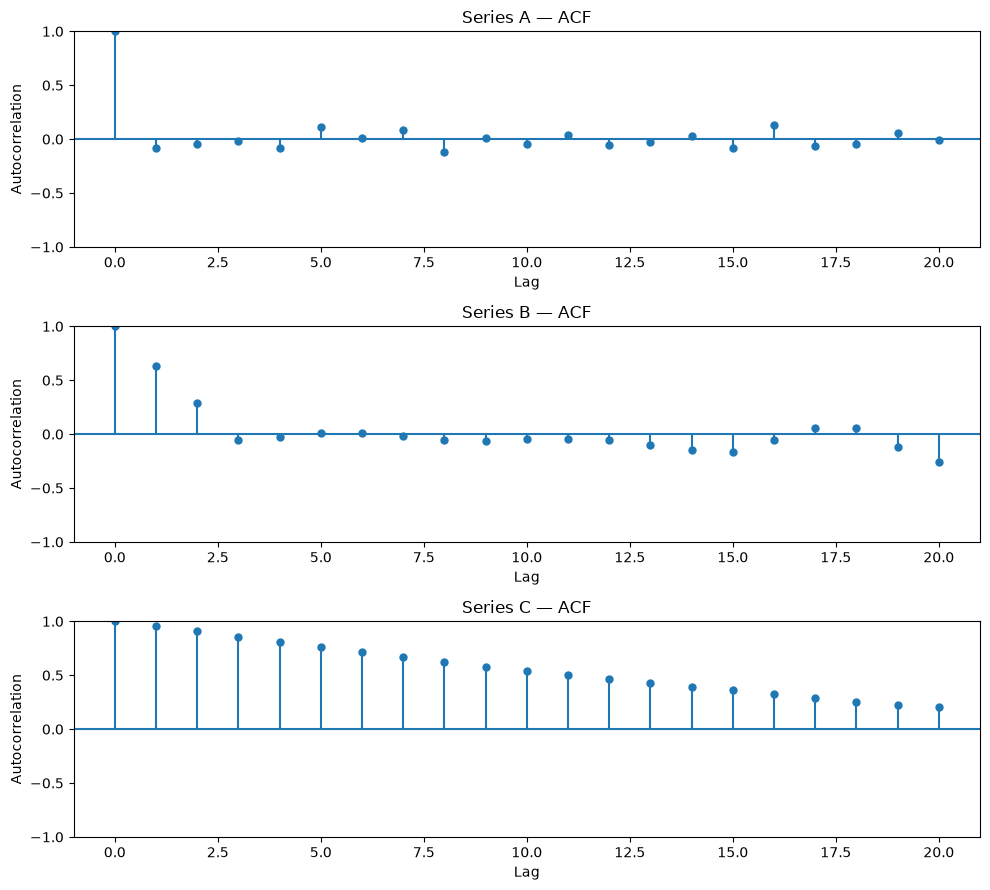

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

for ax, (name, values) in zip(axes, series_dict.items()):
    plot_acf(
        values,
        lags=20,
        alpha=None,
        ax=ax
    )

    ax.set_title(f'{name} — ACF')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()


## 7. Did the ACF change your decision?

For each series:

- What did the time plot suggest?
- What did the ACF add?
- Did you change your original decision?

### Series A
The jagged time plot around a flat mean suggested stationary independence; the ACF stays near zero at all lags (largest magnitude 0.13), confirming it. No change: stationary white noise.

### Series B
The smooth wiggles suggested stationary dependence; the ACF confirms it with 0.635 at lag 1 decaying to 0.292 at lag 2. No change — and this is the key lesson: **stationary does not mean independent**.

### Series C
The wandering level suggested non-stationarity; the ACF confirms persistence with 0.954 at lag 1 decaying only to 0.855 at lag 3. No change: random walk, not stationary.

In [27]:
print("REVEAL")
print("------")
print("Series A = White noise")
print("Series B = Stationary dependent process")
print("Series C = Random walk")


REVEAL
------
Series A = White noise
Series B = Stationary dependent process
Series C = Random walk


### What should we learn?

**Series A — White noise**
- Stationary.
- Little/no autocorrelation at non-zero lags.

**Series B — Stationary dependent process**
- Stationary.
- Has autocorrelation.
- **Stationary does not mean independent.**

**Series C — Random walk**
- Not stationary.
- Its level wanders through time rather than remaining around one stable level.


# 8. Final Evidence Table — Your Rainfall Series

Complete the table using evidence from your analysis.


In [28]:
evidence = pd.DataFrame({
    'Question': [
        'Does the typical level appear stable?',
        'Does variability appear reasonably stable?',
        'Is there a clear trend?',
        'Is there a persistent level shift?',
        'Do earlier and later periods look similar?',
        'Does the dependence / ACF look reasonably similar?'
    ],
    'My evidence': [
        'No — FEB mean 12.19 vs SEP mean 227.46; yearly means 60.9 to 190.9.',
        'Roughly — same order of magnitude, but early sd 68.70 vs late sd 96.22.',
        'No steady trend — annual slope +48.3/yr yet r = 0.318 (year explains ~10%).',
        'No single permanent step, but the mean moves: early 74.07 vs late 102.68.',
        'Same seasonal shape, different level and spread — not reasonably similar.',
        'Yes, broadly — both windows show lag-1 positive with a lag-12 rise.'
    ]
})

display(evidence)

,Question,My evidence
0,Does the typical level appear stable?,No — FEB mean 12.19 vs SEP mean 227.46; yearly...
1,Does variability appear reasonably stable?,"Roughly — same order of magnitude, but early s..."
2,Is there a clear trend?,No steady trend — annual slope +48.3/yr yet r ...
3,Is there a persistent level shift?,"No single permanent step, but the mean moves: ..."
4,Do earlier and later periods look similar?,"Same seasonal shape, different level and sprea..."
5,Does the dependence / ACF look reasonably simi...,"Yes, broadly — both windows show lag-1 positiv..."


# 9. Week 4 Final Conclusion

### My judgement

I think this series is:

- [ ] Stationary-looking
- [x] Not stationary-looking
- [ ] Unsure

### Evidence 1

The typical level changes with the season: February averages 12.19 while September averages 227.46 (a range of 215.3), so the mean depends on the calendar month rather than staying constant.

### Evidence 2

The level also shifts between periods: the first 36 months average 74.07 against 102.68 for the last 36, and yearly means range from 60.9 (2016) to 190.9 (2020).

### Optional additional evidence

Dependence itself looks reasonably stable — both windows show positive lag 1 and a lag-12 rise — and the full-series ACF confirms real dependence with lag 12 strongest (about 0.54 on the plot, 0.567 on pairs). But stable dependence cannot rescue an unstable mean, and a nonzero ACF alone never proves stationarity anyway.

### Limitation

This conclusion is based on visual inspection, descriptive evidence, and the ACF. It does **not formally prove stationarity**.

**Seasonality note:** A repeating monthly seasonal mean can violate stationarity of the raw series. The full-series ACF alone cannot establish that the dependence structure stays unchanged over time.

## Submission check

Before submitting, make sure your Week 4 section contains:

- [ ] Prediction before analysis
- [ ] Full time plot
- [ ] Earlier vs later period comparison
- [ ] Descriptive comparison
- [ ] Full-series ACF
- [ ] Earlier vs later ACF comparison
- [ ] Stationarity Detective activity
- [ ] Final evidence table
- [ ] Final evidence-based conclusion

**Practical outcome:** Add this Week 4 investigation to your individual TSA Colab portfolio.
